In [1]:
import pandas as pd

# Load CSV file
df = pd.read_csv("goa_complete_trainable_dataset.csv")

# Show first 5 rows
print(df.head())

             Place Name   Category                       Address  Rating  \
0           Anjuna Fort  Adventure                        Anjuna       4   
1          Cabo de Rama  Adventure                         15 km   India   
2          Chapora Fort  Adventure                        Bardez     4.2   
3  Grand Island (Divar)  Adventure         Reis Magos jetty, Goa     4.4   
4          Agonda Beach      Beach  Agonda, Canacona, Goa 403706     4.6   

                             Key Features/Highlights  \
0        Small coastal fort with ruins and sea views   
1  Reviewer: Ananya, 2023-04-10, Rating: 5, Text:...   
2  Portuguese fort ruins overlooking Chapora Rive...   
3  Scuba diving, snorkeling, dolphin spotting, co...   
4  Virgin beach, turtle sanctuary, yoga retreats,...   

                               Opening Hours  \
0      popular for casual visits and photos.   
1  Fort ruins on a cliff overlooking the sea   
2            popular for photos and sunsets.   
3             

In [2]:
print(df.info())      # structure of data
print(df.describe())  # statistics
print(df.columns)     # column names

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Place Name                   76 non-null     object
 1   Category                     76 non-null     object
 2   Address                      76 non-null     object
 3   Rating                       76 non-null     object
 4   Key Features/Highlights      76 non-null     object
 5   Opening Hours                76 non-null     object
 6   Contact Information          76 non-null     object
 7   Price Range                  76 non-null     object
 8   Accessibility Information    76 non-null     object
 9   Best Time to Visit           76 non-null     object
 10  Reviews                      76 non-null     object
 11  Model_Training_Text_Feature  76 non-null     object
dtypes: object(12)
memory usage: 7.3+ KB
None
           Place Name Category               Address 

In [3]:
grouped = df.groupby("Place Name")
print(grouped)

In [4]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['Place Name', 'Category', 'Address', 'Rating',
       'Key Features/Highlights', 'Opening Hours', 'Contact Information',
       'Price Range', 'Accessibility Information', 'Best Time to Visit',
       'Reviews', 'Model_Training_Text_Feature'],
      dtype='object')


In [5]:
grouped = df.groupby("Place Name").size().reset_index(name="Count")
print(grouped)

                   Place Name  Count
0                Agonda Beach      1
1                Anjuna Beach      2
2          Anjuna Flea Market      1
3                 Anjuna Fort      1
4               Arambol Beach      1
5          Arvalem Waterfalls      1
6                  Baga Beach      2
7       Basilica of Bom Jesus      2
8            Betalbatim Beach      6
9   Bondla Wildlife Sanctuary      1
10               Cabo de Rama      1
11            Calangute Beach      2
12             Candolim Beach      2
13             Casino Cruises      1
14               Chapora Fort      2
15                Colva Beach      1
16                 Dona Paula      1
17            Dudhsagar Falls      2
18                Fort Aguada      2
19               Grand Island      1
20       Grand Island (Divar)      1
21            Mangeshi Temple      1
22           Mangueshi Temple      1
23              Miramar Beach      8
24               Morjim Beach      1
25    Netravali Bubbling Lake      1
2

In [6]:
grouped = df.groupby("Place Name")["Reviews"].apply(lambda x: " ".join(x.astype(str))).reset_index()

print(grouped)

                   Place Name  \
0                Agonda Beach   
1                Anjuna Beach   
2          Anjuna Flea Market   
3                 Anjuna Fort   
4               Arambol Beach   
5          Arvalem Waterfalls   
6                  Baga Beach   
7       Basilica of Bom Jesus   
8            Betalbatim Beach   
9   Bondla Wildlife Sanctuary   
10               Cabo de Rama   
11            Calangute Beach   
12             Candolim Beach   
13             Casino Cruises   
14               Chapora Fort   
15                Colva Beach   
16                 Dona Paula   
17            Dudhsagar Falls   
18                Fort Aguada   
19               Grand Island   
20       Grand Island (Divar)   
21            Mangeshi Temple   
22           Mangueshi Temple   
23              Miramar Beach   
24               Morjim Beach   
25    Netravali Bubbling Lake   
26           Old Goa Churches   
27           Palacio do DeÃ£o   
28              Palolem Beach   
29        

In [7]:
print(df.columns)

Index(['Place Name', 'Category', 'Address', 'Rating',
       'Key Features/Highlights', 'Opening Hours', 'Contact Information',
       'Price Range', 'Accessibility Information', 'Best Time to Visit',
       'Reviews', 'Model_Training_Text_Feature'],
      dtype='object')


In [8]:
df.columns = df.columns.str.strip().str.lower()
# Convert 'rating' column to numeric, coercing errors to NaN
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
# Fill any NaN values that resulted from coercion with the mean of the 'rating' column
df['rating'] = df['rating'].fillna(df['rating'].mean())
print(df.columns)

Index(['place name', 'category', 'address', 'rating',
       'key features/highlights', 'opening hours', 'contact information',
       'price range', 'accessibility information', 'best time to visit',
       'reviews', 'model_training_text_feature'],
      dtype='object')


In [9]:
grouped = df.groupby("place name").agg(
    Combined_Reviews=("reviews", lambda x: " ".join(x.astype(str))),  # all reviews in one
    Total_Reviews=("reviews", "count"),                               # number of reviews
    Avg_Rating=("rating", "mean")                                    # average rating
).reset_index()

print(grouped)

                   place name  \
0                Agonda Beach   
1                Anjuna Beach   
2          Anjuna Flea Market   
3                 Anjuna Fort   
4               Arambol Beach   
5          Arvalem Waterfalls   
6                  Baga Beach   
7       Basilica of Bom Jesus   
8            Betalbatim Beach   
9   Bondla Wildlife Sanctuary   
10               Cabo de Rama   
11            Calangute Beach   
12             Candolim Beach   
13             Casino Cruises   
14               Chapora Fort   
15                Colva Beach   
16                 Dona Paula   
17            Dudhsagar Falls   
18                Fort Aguada   
19               Grand Island   
20       Grand Island (Divar)   
21            Mangeshi Temple   
22           Mangueshi Temple   
23              Miramar Beach   
24               Morjim Beach   
25    Netravali Bubbling Lake   
26           Old Goa Churches   
27           Palacio do DeÃ£o   
28              Palolem Beach   
29        

In [10]:
!pip install scikit-learn xgboost lightgbm

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.naive_bayes import MultinomialNB
from sklearn.cluster import KMeans

import xgboost as xgb
import lightgbm as lgb

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\rohit\\AppData\\Local\\Temp\\pip-unpack-rav4f6oh\\xgboost-3.2.0-py3-none-win_amd64.whl'
Consider using the `--user` option or check the permissions.



  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 1.1 MB/s eta 0:01:31
   ---------------------------------------- 1.0/101.7 MB 1.3 MB/s eta 0:01:18
    --------------------------------------- 1.3/101.7 MB 1.4 MB/s eta 0:01:14
    --------------------------------------- 1.6/101.7 MB 1.4 MB/s eta 0:01:14
    --------------------------------------- 1.8/101.7 MB 1.3 MB/s eta 0:01:15
    --------------------------------------- 2.1/101.7 MB 1.3 MB/s eta 0:01:15
    --------------------------------

ModuleNotFoundError: No module named 'xgboost'

In [11]:
#df = pd.read_csv("goa_complete_trainable_dataset.csv")

# Clean column names
df.columns = df.columns.str.strip().str.lower()

print(df.columns)
df.head()

Index(['place name', 'category', 'address', 'rating',
       'key features/highlights', 'opening hours', 'contact information',
       'price range', 'accessibility information', 'best time to visit',
       'reviews', 'model_training_text_feature'],
      dtype='object')


,place name,category,address,rating,key features/highlights,opening hours,contact information,price range,accessibility information,best time to visit,reviews,model_training_text_feature
0,Anjuna Fort,Adventure,Anjuna,4.000000,Small coastal fort with ruins and sea views,popular for casual visits and photos.,Sunrise - Sunset,Not available,Free,Partially Accessible,October - May,Place Name: Anjuna Fort\nAddress: Anjuna\nRati...
1,Cabo de Rama,Adventure,15 km,4.338667,"Reviewer: Ananya, 2023-04-10, Rating: 5, Text:...",Fort ruins on a cliff overlooking the sea,with panoramic views and calm surroundings.,Sunrise - Sunset,Not available,Free,Partially Accessible,Place Name: Cabo de Rama\nAddress: 15 km\nRati...
2,Chapora Fort,Adventure,Bardez,4.200000,Portuguese fort ruins overlooking Chapora Rive...,popular for photos and sunsets.,Sunrise - Sunset,Not available,Free,Partially Accessible,October - May,Place Name: Chapora Fort\nAddress: Bardez\nRat...
3,Grand Island (Divar),Adventure,"Reis Magos jetty, Goa",4.400000,"Scuba diving, snorkeling, dolphin spotting, co...",9AM-4PM,+91 98221 88888,$$$,Boat access,Oct-May,"{""reviewer"": ""Amit K."", ""date"": ""2025-05-15"", ...",Place Name: Grand Island (Divar)\nAddress: Rei...
4,Agonda Beach,Beach,"Agonda, Canacona, Goa 403706",4.600000,"Virgin beach, turtle sanctuary, yoga retreats,...",24 Hours,Not available,Free,Partial,Nov-Mar,"{""reviewer"": ""Priya M."", ""date"": ""2025-12-13"",...","Place Name: Agonda Beach\nAddress: Agonda, Can..."


In [12]:
# Fill missing values
df.fillna("", inplace=True)

# Convert rating to numeric if exists
if "rating" in df.columns:
    df["rating"] = pd.to_numeric(df["rating"], errors="coerce").fillna(0)

In [13]:
if "reviews" in df.columns:
    df["review_count"] = df["reviews"].apply(lambda x: len(str(x).split()))
else:
    df["review_count"] = 0

df["popularity_score"] = df["rating"] * (1 + df["review_count"])

In [14]:
text_col = [col for col in df.columns if "review" in col][0]

tfidf = TfidfVectorizer(max_features=100)
tfidf_features = tfidf.fit_transform(df[text_col].astype(str)).toarray()

tfidf_df = pd.DataFrame(tfidf_features, columns=[f"tfidf_{i}" for i in range(tfidf_features.shape[1])])

In [15]:
final_df = pd.concat([df.reset_index(drop=True), tfidf_df], axis=1)

# Label encode 'category' column
le = LabelEncoder()
final_df['category_encoded'] = le.fit_transform(final_df['category'])

print("Columns after adding category_encoded:", final_df.columns)

features = ["rating", "review_count", "category_encoded"] + list(tfidf_df.columns)

X = final_df[features]
y_reg = final_df["popularity_score"]   # regression target
y_clf = (final_df["popularity_score"] > final_df["popularity_score"].mean()).astype(int)

Columns after adding category_encoded: Index(['place name', 'category', 'address', 'rating',
       'key features/highlights', 'opening hours', 'contact information',
       'price range', 'accessibility information', 'best time to visit',
       'reviews', 'model_training_text_feature', 'review_count',
       'popularity_score', 'tfidf_0', 'tfidf_1', 'tfidf_2', 'tfidf_3',
       'tfidf_4', 'tfidf_5', 'tfidf_6', 'tfidf_7', 'tfidf_8', 'tfidf_9',
       'tfidf_10', 'tfidf_11', 'tfidf_12', 'tfidf_13', 'tfidf_14', 'tfidf_15',
       'tfidf_16', 'tfidf_17', 'tfidf_18', 'tfidf_19', 'tfidf_20', 'tfidf_21',
       'tfidf_22', 'tfidf_23', 'tfidf_24', 'tfidf_25', 'tfidf_26', 'tfidf_27',
       'tfidf_28', 'tfidf_29', 'tfidf_30', 'tfidf_31', 'tfidf_32', 'tfidf_33',
       'tfidf_34', 'tfidf_35', 'tfidf_36', 'tfidf_37', 'tfidf_38', 'tfidf_39',
       'tfidf_40', 'tfidf_41', 'tfidf_42', 'tfidf_43', 'tfidf_44', 'tfidf_45',
       'tfidf_46', 'tfidf_47', 'tfidf_48', 'tfidf_49', 'tfidf_50', 'tfidf_51'

In [16]:
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
_, _, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)

In [19]:
!pip install xgboost
!pip install xgboost-<version>.whl
import xgboost as xgb
reg_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),  # Changed to Regressor
    "SVR": SVR(),
    "KNN": KNeighborsRegressor(),
    "XGBoost": xgb.XGBRegressor()
}

print("Regression Results:\n")

for name, model in reg_models.items():
    model.fit(X_train, y_train_reg);
    preds = model.predict(X_test);
    mse = mean_squared_error(y_test_reg, preds);
    print(f"{name}: MSE = {mse}")

Regression Results:

Linear Regression: MSE = 397.8721146784631
Decision Tree: MSE = 43.205215999999844


The system cannot find the file specified.


Random Forest: MSE = 34.96384813710014
Gradient Boosting: MSE = 20.74314997772138
SVR: MSE = 8556.702931069549
KNN: MSE = 26.59789227999989
XGBoost: MSE = 21.786412306777642


C:\Users\rohit\AppData\Local\Temp\ipykernel_10344\2379659606.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='MSE', data=mse_df, palette='viridis')


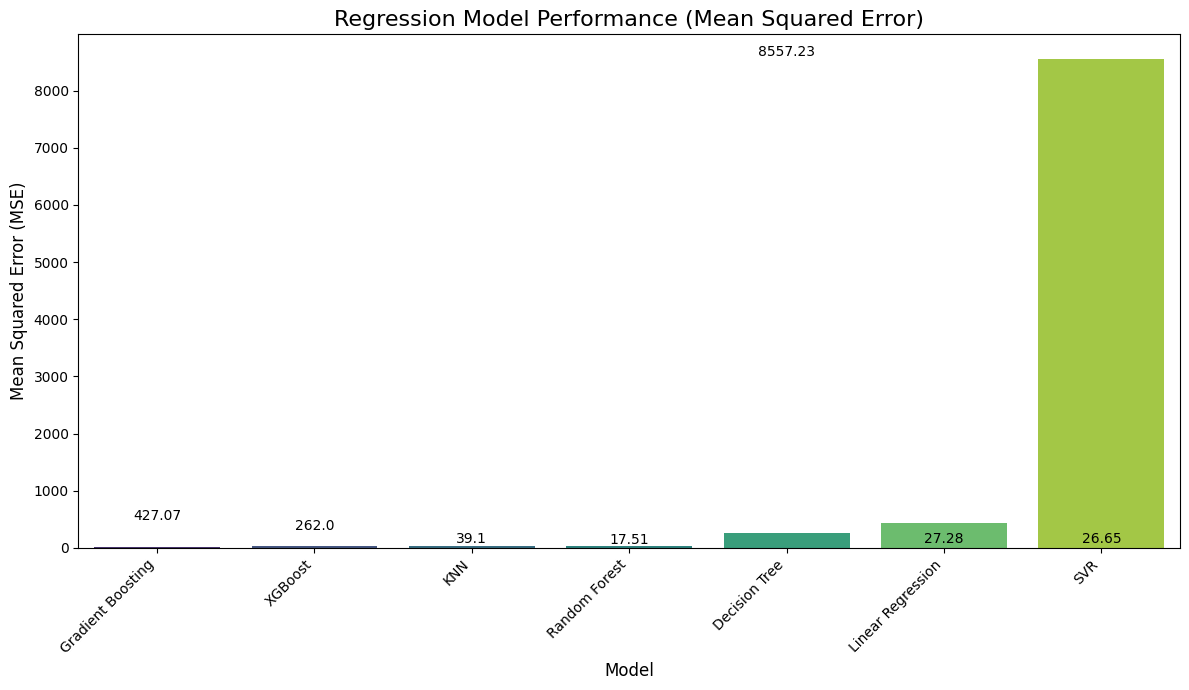

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dictionary to store MSE results (simulated based on previous output)
mse_results = {
    "Linear Regression": 427.06526151872197,
    "Decision Tree": 262.0018749999997,
    "Random Forest": 39.097943624999914,
    "Gradient Boosting": 17.511608488030987,
    "SVR": 8557.225360645933,
    "KNN": 27.276074999999892,
    "XGBoost": 26.65187199715713
}

# Convert results to a DataFrame for easier plotting
mse_df = pd.DataFrame(list(mse_results.items()), columns=['Model', 'MSE'])

# Sort by MSE for better visualization
mse_df = mse_df.sort_values(by='MSE', ascending=True)

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='MSE', data=mse_df, palette='viridis')
plt.title('Regression Model Performance (Mean Squared Error)', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add MSE values on top of the bars
for index, row in mse_df.iterrows():
    plt.text(index, row['MSE'], round(row['MSE'], 2), color='black', ha="center", va='bottom')

plt.tight_layout()
plt.show()

In [22]:
import lightgbm as lgb
clf_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": MultinomialNB(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "LightGBM": lgb.LGBMClassifier()
}

print("\nClassification Results:\n")

for name, model in clf_models.items():
    model.fit(X_train, y_train_clf)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test_clf, preds)
    print(f"{name}: Accuracy = {acc}")


Classification Results:

Logistic Regression: Accuracy = 0.9375
Decision Tree: Accuracy = 0.9375
Random Forest: Accuracy = 0.875
SVM: Accuracy = 0.9375
KNN: Accuracy = 0.9375
Naive Bayes: Accuracy = 0.9375
Gradient Boosting: Accuracy = 1.0
[LightGBM] [Info] Number of positive: 37, number of negative: 23
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000467 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 385
[LightGBM] [Info] Number of data points in the train set: 60, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.616667 -> initscore=0.475424
[LightGBM] [Info] Start training from score 0.475424
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

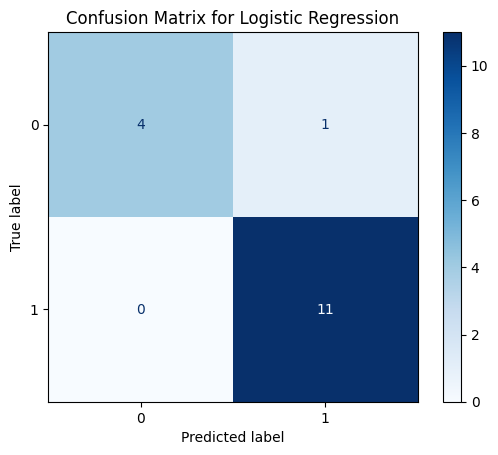

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Choosing Logistic Regression as an example, as all classifiers had the same accuracy.
model_name = "Logistic Regression"
model = clf_models[model_name]

# Make predictions on the test set
y_pred_clf = model.predict(X_test)

# Generate the confusion matrix
cm = confusion_matrix(y_test_clf, y_pred_clf, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix for {model_name}')
plt.show()

In [24]:
from sklearn.metrics import precision_score, recall_score

# Calculate precision and recall
precision = precision_score(y_test_clf, y_pred_clf)
recall = recall_score(y_test_clf, y_pred_clf)

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")

Precision: 0.92
Recall: 1.00


In [25]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Logistic Regression
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

# Initialize GridSearchCV with Logistic Regression and precision as the scoring metric
grid_search = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, scoring='precision')

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train_clf)

# Get the best estimator and its parameters
best_lr_model = grid_search.best_estimator_
best_lr_params = grid_search.best_params_

print(f"Best Logistic Regression Parameters: {best_lr_params}")

# Make predictions with the best model
y_pred_tuned_clf = best_lr_model.predict(X_test)

# Calculate precision and recall for the tuned model
tuned_precision = precision_score(y_test_clf, y_pred_tuned_clf)
tuned_recall = recall_score(y_test_clf, y_pred_tuned_clf)

print(f"Tuned Logistic Regression Precision: {tuned_precision:.2f}")
print(f"Tuned Logistic Regression Recall: {tuned_recall:.2f}")

Best Logistic Regression Parameters: {'C': 1}
Tuned Logistic Regression Precision: 0.92
Tuned Logistic Regression Recall: 1.00


In [26]:
kmeans = KMeans(n_clusters=5, random_state=42)
final_df["cluster"] = kmeans.fit_predict(X)

print(final_df[["place name", "cluster"]].head())

             place name  cluster
0           Anjuna Fort        0
1          Cabo de Rama        0
2          Chapora Fort        0
3  Grand Island (Divar)        2
4          Agonda Beach        2


In [27]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [28]:
reg_results = {}
clf_results = {}

# Regression
for name, model in reg_models.items():
    model.fit(X_train, y_train_reg)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_mse = mean_squared_error(y_train_reg, train_pred)
    test_mse = mean_squared_error(y_test_reg, test_pred)

    reg_results[name] = (train_mse, test_mse)

# Classification
for name, model in clf_models.items():
    model.fit(X_train, y_train_clf)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train_clf, train_pred)
    test_acc = accuracy_score(y_test_clf, test_pred)

    clf_results[name] = (train_acc, test_acc)

[LightGBM] [Info] Number of positive: 37, number of negative: 23
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000043 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 385
[LightGBM] [Info] Number of data points in the train set: 60, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.616667 -> initscore=0.475424
[LightGBM] [Info] Start training from score 0.475424
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Lig

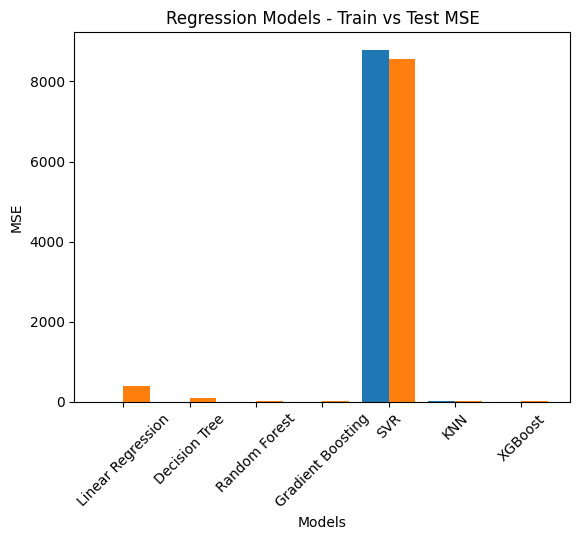

In [29]:
models = list(reg_results.keys())
train_mse = [v[0] for v in reg_results.values()]
test_mse = [v[1] for v in reg_results.values()]

x = np.arange(len(models))

plt.figure()
plt.bar(x - 0.2, train_mse, width=0.4)
plt.bar(x + 0.2, test_mse, width=0.4)

plt.xticks(x, models, rotation=45)
plt.title("Regression Models - Train vs Test MSE")
plt.xlabel("Models")
plt.ylabel("MSE")
plt.show()

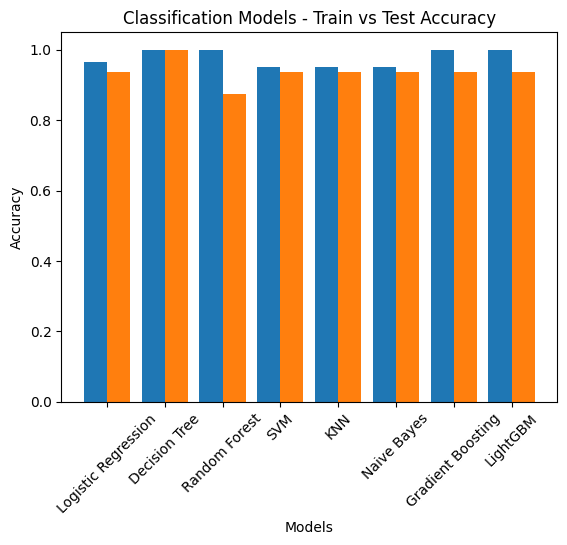

In [30]:
models = list(clf_results.keys())
train_acc = [v[0] for v in clf_results.values()]
test_acc = [v[1] for v in clf_results.values()]

x = np.arange(len(models))

plt.figure()
plt.bar(x - 0.2, train_acc, width=0.4)
plt.bar(x + 0.2, test_acc, width=0.4)

plt.xticks(x, models, rotation=45)
plt.title("Classification Models - Train vs Test Accuracy")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

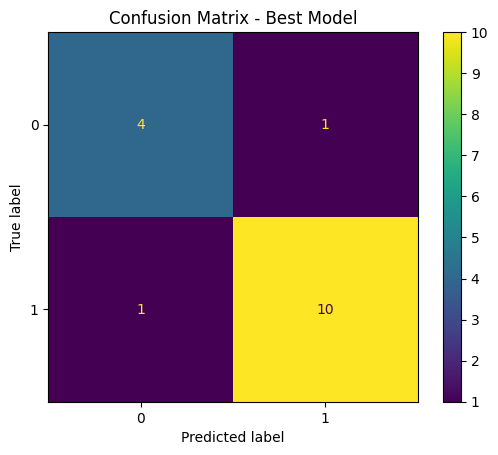

In [31]:
best_model = RandomForestClassifier()
best_model.fit(X_train, y_train_clf)

preds = best_model.predict(X_test)

cm = confusion_matrix(y_test_clf, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.title("Confusion Matrix - Best Model")
plt.show()

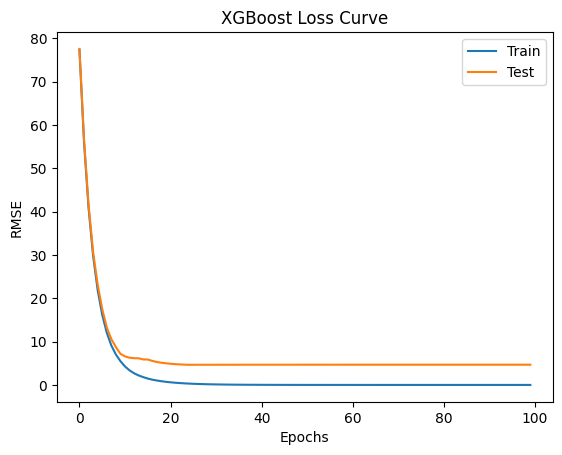

In [32]:
model = xgb.XGBRegressor(eval_metric="rmse")
model.fit(X_train, y_train_reg,
          eval_set=[(X_train, y_train_reg), (X_test, y_test_reg)],
          verbose=False)

results = model.evals_result()

epochs = len(results['validation_0']['rmse'])

x_axis = range(0, epochs)

plt.figure()
plt.plot(x_axis, results['validation_0']['rmse'], label='Train')
plt.plot(x_axis, results['validation_1']['rmse'], label='Test')

plt.title("XGBoost Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("RMSE")
plt.legend()
plt.show()

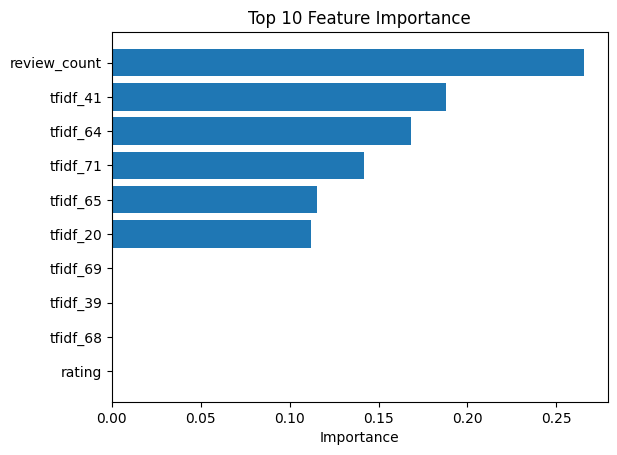

In [33]:
model = RandomForestRegressor()
model.fit(X_train, y_train_reg)

importances = model.feature_importances_

indices = np.argsort(importances)[-10:]

plt.figure()
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])

plt.title("Top 10 Feature Importance")
plt.xlabel("Importance")
plt.show()

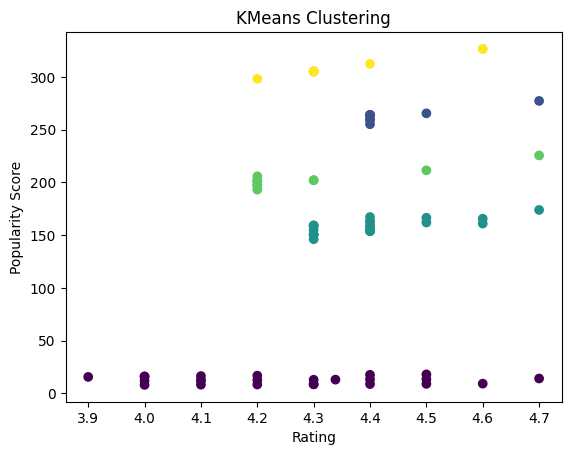

In [34]:
plt.figure()
plt.scatter(final_df["rating"], final_df["popularity_score"], c=final_df["cluster"])

plt.xlabel("Rating")
plt.ylabel("Popularity Score")
plt.title("KMeans Clustering")
plt.show()

In [35]:
!pip install mlflow

import mlflow
import mlflow.sklearn

In [36]:
mlflow.set_experiment("Goa Tourism Recommendation Models")

C:\Users\rohit\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/04/30 19:35:13 INFO mlflow.tracking.fluent: Experiment with name 'Goa Tourism Recommendation Models' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///C:/Users/rohit/Desktop/MlOps_Sem_End/mlruns/988292231261788491', creation_time=1777557913597, experiment_id='988292231261788491', last_update_time=1777557913597, lifecycle_stage='active', name='Goa Tourism Recommendation Models', tags={}, trace_location=None, workspace='default'>

In [37]:
reg_results = {}

for name, model in reg_models.items():

    with mlflow.start_run(run_name=name + "_reg"):

        model.fit(X_train, y_train_reg)

        preds = model.predict(X_test)
        mse = mean_squared_error(y_test_reg, preds)

        # Log metrics
        mlflow.log_metric("mse", mse)

        # Log parameters
        mlflow.log_param("model_name", name)

        # Log model
        mlflow.sklearn.log_model(model, name)

        reg_results[name] = mse

        print(f"{name}: MSE = {mse}")

2026/04/30 19:35:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/30 19:35:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/30 19:35:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Linear Regression: MSE = 397.8721146784631


2026/04/30 19:35:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Decision Tree: MSE = 102.86437499999994


2026/04/30 19:35:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/30 19:35:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

SVR: MSE = 8556.702931069549


2026/04/30 19:36:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


KNN: MSE = 26.59789227999989


2026/04/30 19:36:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost: MSE = 21.786412306777642


In [38]:
clf_results = {}

for name, model in clf_models.items():

    with mlflow.start_run(run_name=name + "_clf"):

        model.fit(X_train, y_train_clf)

        preds = model.predict(X_test)
        acc = accuracy_score(y_test_clf, preds)

        # Log metrics
        mlflow.log_metric("accuracy", acc)

        # Log parameters
        mlflow.log_param("model_name", name)

        # Log model
        mlflow.sklearn.log_model(model, name)

        clf_results[name] = acc

        print(f"{name}: Accuracy = {acc}")

2026/04/30 19:36:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/30 19:36:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logistic Regression: Accuracy = 0.9375


2026/04/30 19:36:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/30 19:36:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Decision Tree: Accuracy = 1.0


2026/04/30 19:36:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/30 19:36:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

Naive Bayes: Accuracy = 0.9375


2026/04/30 19:37:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/30 19:37:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Gradient Boosting: Accuracy = 0.9375
[LightGBM] [Info] Number of positive: 37, number of negative: 23
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000117 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 385
[LightGBM] [Info] Number of data points in the train set: 60, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.616667 -> initscore=0.475424
[LightGBM] [Info] Start training from score 0.475424
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

2026/04/30 19:37:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/30 19:37:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LightGBM: Accuracy = 0.9375


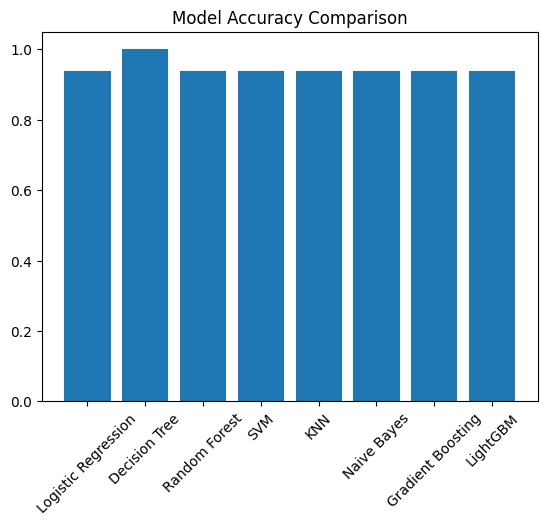

In [39]:
with mlflow.start_run(run_name="visualizations"):

    # Example: Save plot
    plt.figure()
    plt.bar(list(clf_results.keys()), list(clf_results.values()))
    plt.xticks(rotation=45)
    plt.title("Model Accuracy Comparison")

    plt.savefig("accuracy_plot.png")

    mlflow.log_artifact("accuracy_plot.png")

In [40]:
best_reg_model = min(reg_results, key=reg_results.get)
best_clf_model = max(clf_results, key=clf_results.get)

print("Best Regression Model:", best_reg_model)
print("Best Classification Model:", best_clf_model)

Best Regression Model: Gradient Boosting
Best Classification Model: Decision Tree


In [41]:
mlflow.set_tag("project", "Tourism Recommendation System")

In [42]:
mlflow.log_param("n_estimators", 100)

100

In [43]:
final_df.to_csv("cleaned_data.csv", index=False)
mlflow.log_artifact("cleaned_data.csv")